# The fuel shock stress test, tested by a real fuel shock (v1.0)

**Version 0.3** (July 2026) simulated Brent crude with a mean-reverting (Ornstein-Uhlenbeck) Monte Carlo,
passed crude moves through to diesel and then to operating margins, and concluded:

1. 16 of 22 listed trucking and logistics companies (73%) had more than a 5% chance of an operating
   margin below zero within 12 months;
2. margin discipline predicts survival far better than scale (correlation -0.75 against -0.34).

Between March and June 2026, Brent went from about $70 to a monthly average of $117 and a peak of $138:
the kind of shock the model was built for. The companies have since reported their results for the
quarter. This notebook:

1. reproduces v0.3;
2. shows why its second finding was guaranteed by the model's construction;
3. re-estimates crude-to-diesel pass-through properly and tests it on 2026;
4. checks how much the Monte Carlo's answer depends on its oil-price parameters;
5. compares the model with the companies' reported margins in the 2026 shock.

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import monte_carlo as mc  # noqa: E402
from company_survival import margin_path_for_company  # noqa: E402

DATA = ROOT / "data" / "public"
FIG = ROOT / "charts"
R = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")


brent = pd.read_csv(DATA / "brent_usd_bbl_daily.csv", parse_dates=["date"]).set_index("date")["value"]
diesel = pd.read_csv(DATA / "us_diesel_usd_gal_weekly.csv", parse_dates=["date"]).set_index("date")["value"]
screen = pd.read_csv(DATA / "company_screen.csv")
print(f"Brent daily {brent.index.min().date()} to {brent.index.max().date()}; US diesel weekly {diesel.index.min().date()} to {diesel.index.max().date()}")

Brent daily 1987-05-20 to 2026-06-29; US diesel weekly 1994-03-21 to 2026-06-29


## 1. Reproduce v0.3

In [2]:
params = mc.calibrate_ou(brent)
paths = mc.simulate_ou_paths(params, mc.HORIZON_MONTHS, mc.N_PATHS, mc.SEED)
rows = []
for _, r in screen.iterrows():
    if pd.isna(r["operatingMargins"]) or r["country"] not in mc.COUNTRIES:
        continue
    m = margin_path_for_company(paths, params["last_price"], r["operatingMargins"], r["country"])
    c = mc.COUNTRIES[r["country"]]
    rows.append({"ticker": r["ticker"], "country": r["country"], "margin0": r["operatingMargins"], "revenue": r["totalRevenue"],
                 "sensitivity": c["fuel_share_rev"] * c["beta"], "p_breach": float((m < 0).any(axis=1).mean())})
co = pd.DataFrame(rows)
co["log_revenue"] = np.log(co["revenue"])
R["ou"] = {k: float(v) for k, v in params.items() if k != "last_date"}
R["ou_half_life_years"] = float(np.log(2) / params["theta"])
R["v03_companies"], R["v03_over5pct"] = len(co), int((co["p_breach"] > 0.05).sum())
R["v03_corr_margin"] = float(np.corrcoef(co["margin0"], co["p_breach"])[0, 1])
R["v03_corr_logrev"] = float(np.corrcoef(co["log_revenue"], co["p_breach"])[0, 1])
print(f"OU: half-life {R['ou_half_life_years']:.2f} years, long-run mean ${params['mu_level']:.1f}, volatility {params['sigma_annual']:.2f}")
print(f"{R['v03_over5pct']} of {len(co)} companies above a 5% breach chance; correlation with margin {R['v03_corr_margin']:.2f}, "
      f"with log revenue {R['v03_corr_logrev']:.2f}")

OU: half-life 0.87 years, long-run mean $73.2, volatility 0.43
16 of 22 companies above a 5% breach chance; correlation with margin -0.75, with log revenue -0.34


v0.3 reproduces exactly: 16 of 22 companies, correlations of -0.75 with margin and -0.34 with size.

## 2. Why "margin beats scale" was guaranteed

In the model, a company's margin path is

$$m_t = m_0 - s \cdot \frac{P_t - P_0}{P_0} \cdot (1 - \text{ramp}_t), \qquad s = \text{fuel share of revenue} \times \text{crude-to-diesel beta},$$

and the only company-specific input is $m_0$, its trailing operating margin; $s$ is the same for every
company in a country. Revenue, size and balance sheet never enter. So the chance of $m_t$ touching zero
depends on one number, the **distance to zero in units of fuel sensitivity**, $m_0 / s$: a company
breaches when crude rises by more than $m_0 / s$ (adjusted for the ramp). Plotting the simulated breach
probability against $m_0 / s$ shows every company on one curve.

Spearman correlation between distance-to-zero and breach chance: -1.000
     ticker country  margin0  sensitivity  distance  p_breach
       MRTN      US    0.001        0.087     0.010     0.876
       ARCB      US    0.004        0.087     0.041     0.810
   LOGN3.SA  Brazil    0.016        0.301     0.052     0.787
ALLCARGO.NS   India    0.016        0.233     0.067     0.752
       WERN      US    0.008        0.087     0.087     0.705
   JSLG3.SA  Brazil    0.032        0.301     0.106     0.653
  MAHLOG.NS   India    0.025        0.233     0.108     0.648
  601598.SS   China    0.033        0.233     0.141     0.568
        KNX      US    0.012        0.087     0.143     0.561
  002352.SZ   China    0.050        0.233     0.216     0.386
       SNDR      US    0.024        0.087     0.274     0.275
  TCIEXP.NS   India    0.068        0.233     0.291     0.247
   RAPT4.SA  Brazil    0.091        0.301     0.302     0.229
     TCI.NS   India    0.081        0.233     0.346     0.16

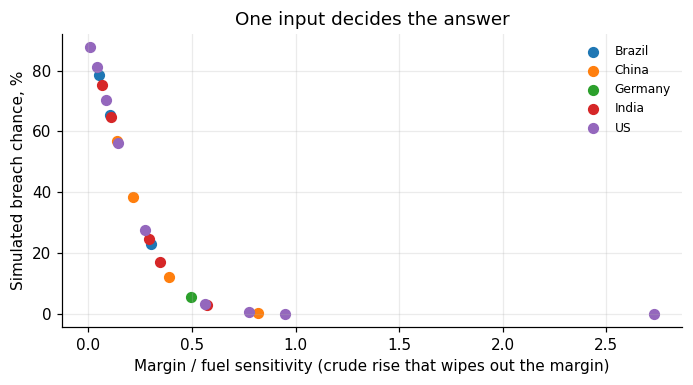

In [3]:
co["distance"] = co["margin0"] / co["sensitivity"]
rho = spearmanr(co["distance"], co["p_breach"])[0]
R["rank_corr_distance_breach"] = float(rho)
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for ctry, g in co.groupby("country"):
    ax.scatter(g["distance"], g["p_breach"] * 100, label=ctry, s=40)
ax.set(xlabel="Margin / fuel sensitivity (crude rise that wipes out the margin)", ylabel="Simulated breach chance, %",
       title="One input decides the answer")
ax.legend(frameon=False, fontsize=8)
save(fig, "05_distance_to_zero.png")
print(f"Spearman correlation between distance-to-zero and breach chance: {rho:.3f}")
print(co.sort_values("distance")[["ticker", "country", "margin0", "sensitivity", "distance", "p_breach"]].round(3).to_string(index=False))

The rank correlation is exactly -1: **the breach probability is a deterministic, decreasing function of
one number**, how far a company's margin sits above zero relative to its country's fuel sensitivity. The
"finding" that margin predicts survival better than scale was built into the model, which never sees
scale at all; the -0.34 with revenue is only revenue's correlation with margin in this sample. And the
companies at the top of the list, Marten (0.1% margin), ArcBest (0.4%) and Werner (0.8%), were near zero
before any oil shock: their high "breach chance" says their margins were thin, not that oil threatens
them more than anyone else.

## 3. Crude-to-diesel pass-through, estimated properly

v0.3's US beta of 0.36 came from regressing 13-week percentage changes in diesel on 13-week changes in
crude, sampled every week. Consecutive 13-week windows share 12 weeks, so the 1,672 observations are
far from independent and the reported precision overstates the evidence. A standard alternative is an
**error-correction model** on weekly data:

- the long run: $\ln D_t = a + b \ln B_t$ (diesel and Brent move together in levels);
- the short run: $\Delta \ln D_t = c + \sum_{j=0}^{4} (\gamma_j^{+} \Delta \ln B_{t-j}^{+} + \gamma_j^{-} \Delta \ln B_{t-j}^{-}) + \alpha\,\text{gap}_{t-1} + \varepsilon_t$,

where $\text{gap}_{t-1}$ is last week's distance from the long-run relation and $\Delta^{+}$, $\Delta^{-}$
split crude rises from falls, which tests the "rockets and feathers" claim that pump prices rise faster
than they fall. Fitted on 1994 to 2025, then tested on 2026, which the fit never saw.

In [4]:
wk = pd.concat({"D": diesel, "B": brent.resample("W-MON").mean().reindex(diesel.index, method="nearest")}, axis=1).dropna()
wk = np.log(wk)
fit_end = pd.Timestamp("2025-12-31")
train = wk[wk.index <= fit_end]
lr = sm.OLS(train["D"], sm.add_constant(train["B"])).fit()
b_long = float(lr.params["B"])
wk["gap"] = wk["D"] - (lr.params["const"] + b_long * wk["B"])
dB = wk["B"].diff()
X = pd.DataFrame(index=wk.index)
for j in range(5):
    X[f"up{j}"] = dB.clip(lower=0).shift(j)
    X[f"down{j}"] = dB.clip(upper=0).shift(j)
X["gap_lag"] = wk["gap"].shift(1)
y = wk["D"].diff()
dfm = pd.concat([y.rename("dD"), X], axis=1).dropna()
tr = dfm[dfm.index <= fit_end]
ecm = sm.OLS(tr["dD"], sm.add_constant(tr.drop(columns="dD"))).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
up_sum = float(sum(ecm.params[f"up{j}"] for j in range(5)))
down_sum = float(sum(ecm.params[f"down{j}"] for j in range(5)))
wald = ecm.wald_test(" + ".join(f"up{j}" for j in range(5)) + " = " + " + ".join(f"down{j}" for j in range(5)), scalar=True)
R.update({"passthrough_long_run": b_long, "ecm_alpha": float(ecm.params["gap_lag"]), "ecm_up_5wk": up_sum, "ecm_down_5wk": down_sum,
          "ecm_asymmetry_p": float(wald.pvalue), "ecm_weeks": int(len(tr))})
print(f"long-run elasticity of diesel to Brent: {b_long:.3f}")
print(f"error correction: {abs(ecm.params['gap_lag']):.3f} of the gap closes each week (half-life {np.log(0.5) / np.log(1 + ecm.params['gap_lag']):.1f} weeks)")
print(f"5-week response to a 1% crude rise: {up_sum:.3f}%; to a 1% fall: {down_sum:.3f}%; equal? p = {wald.pvalue:.3f}")

long-run elasticity of diesel to Brent: 0.704
error correction: 0.015 of the gap closes each week (half-life 44.8 weeks)
5-week response to a 1% crude rise: 0.332%; to a 1% fall: 0.356%; equal? p = 0.835


Three results:

- **In the short run v0.3's 0.36 was about right**: within five weeks, a 1% move in Brent moves US
  diesel by about 0.33 to 0.36%.
- **In the long run pass-through is twice that**: the levels relation gives an elasticity of 0.70, but
  the gap closes slowly (1.5% a week). A 12-month stress test that uses the short-run 0.36 understates
  the cost of a shock that lasts.
- **No rockets and feathers in US diesel**: rises and falls pass through at statistically the same pace
  (p = 0.84).

February to April 2026 averages: Brent +65.5%, US diesel +47.8% (ratio 0.73, against v0.3's beta of 0.36)
peak diesel $5.64/gal against $4.29 predicted from crude; largest gap 32.4%


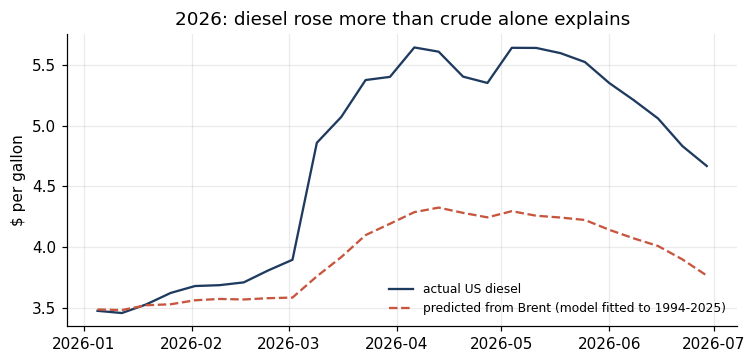

In [5]:
def simulate_ecm(start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    """Diesel path implied by the 1994-2025 model, given actual Brent, from the last pre-shock week."""
    w = wk[(wk.index >= start - pd.Timedelta(weeks=6)) & (wk.index <= end)].copy()
    d = w["D"].copy()
    idx = list(w.index)
    first = next(i for i, t in enumerate(idx) if t >= start)
    p = ecm.params
    for i in range(first, len(idx)):
        dd = p["const"] + p["gap_lag"] * (d.iloc[i - 1] - (lr.params["const"] + b_long * w["B"].iloc[i - 1]))
        for j in range(5):
            db = w["B"].iloc[i - j] - w["B"].iloc[i - j - 1]
            dd += p[f"up{j}"] * max(db, 0) + p[f"down{j}"] * min(db, 0)
        d.iloc[i] = d.iloc[i - 1] + dd
    return np.exp(d[d.index >= start])


sim = simulate_ecm(pd.Timestamp("2026-01-05"), wk.index.max())
act = np.exp(wk.loc[sim.index, "D"])
gap26 = (act / sim - 1)
R["diesel_2026_peak_actual"] = float(act.max())
R["diesel_2026_peak_model"] = float(sim.loc[act.idxmax()])
R["diesel_2026_max_gap"] = float(gap26.max())
feb = (brent["2026-02"].mean(), np.exp(wk.loc["2026-02", "D"]).mean())
apr = (brent["2026-04"].mean(), np.exp(wk.loc["2026-04", "D"]).mean())
R["shock_brent_feb_apr"] = float(apr[0] / feb[0] - 1)
R["shock_diesel_feb_apr"] = float(apr[1] / feb[1] - 1)
R["shock_ratio"] = R["shock_diesel_feb_apr"] / R["shock_brent_feb_apr"]
print(f"February to April 2026 averages: Brent {R['shock_brent_feb_apr']:+.1%}, US diesel {R['shock_diesel_feb_apr']:+.1%} "
      f"(ratio {R['shock_ratio']:.2f}, against v0.3's beta of 0.36)")
print(f"peak diesel ${act.max():.2f}/gal against ${sim.loc[act.idxmax()]:.2f} predicted from crude; largest gap {gap26.max():.1%}")
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(act.index, act, color=INK, label="actual US diesel")
ax.plot(sim.index, sim, color=WARM, ls="--", label="predicted from Brent (model fitted to 1994-2025)")
ax.set(ylabel="$ per gallon", title="2026: diesel rose more than crude alone explains")
ax.legend(frameon=False, fontsize=8)
save(fig, "06_diesel_2026.png")

From February to April 2026, Brent's monthly average rose 65.5% and US diesel's 47.8%: a ratio of 0.73,
twice the beta v0.3 used. The model fitted on 1994 to 2025 predicted a peak near $4.29 a gallon; diesel
reached $5.64, 32% higher. A supply shock centred on the Strait of Hormuz hit refined products harder than
crude, so the refining margin, not crude, carried much of the move. Any crude-only stress test misses
that.

## 4. How much does the Monte Carlo depend on its oil parameters?

The OU parameters come from one AR(1) regression on daily log Brent since 2010. Mean-reversion speed is
notoriously hard to pin down from one realised path: estimated half-lives are biased short in finite
samples and swing between periods. Two checks: the half-life estimated on rolling five-year windows, and
the headline share re-run at half-lives from 6 months to 4 years.

In [6]:
roll = []
for end in pd.date_range("2015-01-01", "2026-06-30", freq="6MS"):
    s = brent[(brent.index > end - pd.DateOffset(years=5)) & (brent.index <= end)]
    if len(s) > 1000:
        p = mc.calibrate_ou(s, start=str(s.index.min().date()))
        # theta <= 0 means the AR(1) coefficient is 1 or more: no mean reversion in that window
        roll.append({"window_end": end.date(), "half_life_years": float(np.log(2) / p["theta"]) if p["theta"] > 0 else np.nan})
roll = pd.DataFrame(roll)
ok = roll["half_life_years"].dropna()
R["rolling_windows"], R["rolling_windows_no_reversion"] = len(roll), int(roll["half_life_years"].isna().sum())
R["rolling_half_life_min"], R["rolling_half_life_max"] = float(ok.min()), float(ok.max())
print(f"{len(roll)} rolling 5-year windows: {R['rolling_windows_no_reversion']} show no mean reversion at all; "
      f"in the rest the half-life ranges from {ok.min():.2f} to {ok.max():.2f} years")
sens = []
for hl in (0.5, R["ou_half_life_years"], 2.0, 4.0):
    pp = dict(params, theta=np.log(2) / hl)
    ps = mc.simulate_ou_paths(pp, mc.HORIZON_MONTHS, mc.N_PATHS, mc.SEED)
    k = 0
    for _, r in co.iterrows():
        m = margin_path_for_company(ps, params["last_price"], r["margin0"], r["country"])
        k += int((m < 0).any(axis=1).mean() > 0.05)
    sens.append({"half_life_years": round(hl, 2), "companies_over_5pct": k})
sens = pd.DataFrame(sens)
R["half_life_sensitivity"] = sens.to_dict(orient="records")
print(sens.to_string(index=False))

23 rolling 5-year windows: 2 show no mean reversion at all; in the rest the half-life ranges from 0.25 to 4.80 years


 half_life_years  companies_over_5pct
            0.50                   15
            0.87                   16
            2.00                   17
            4.00                   18


The mean-reversion estimate is unstable: two of 23 five-year windows show none at all, and the rest
range from 3 months to nearly 5 years. Yet the headline barely moves across that range (15 to 18
companies). That is not reassurance about the model; it is a sign that the headline is driven by
which companies start near zero, not by anything about oil.

## 5. What actually happened to the companies in 2026

Reported operating margins (operating income over revenue, Yahoo Finance, `src/fetch_quarterly_margins.py`)
for the quarter ending June 2026, the peak of the shock (Brent averaged about $103 over April to June),
compared with the same quarter of 2025 to remove seasonality. The model's prediction for that quarter
uses the same mechanics as v0.3: the realised rise in Brent from February, each country's fuel share and
beta, and the 50% surcharge pass-through that ramps in after two months.

In [7]:
q = pd.read_csv(DATA / "quarterly_margins.csv", parse_dates=["quarter_end"])
q["q"] = q["quarter_end"].dt.strftime("%Y-%m")
qm = q.pivot_table(index=["ticker", "country"], columns="q", values="operating_margin").reset_index()
pre = brent["2026-02"].mean()
q2 = brent["2026-04":"2026-06"].resample("M").mean()
bt = qm.dropna(subset=["2025-06", "2026-06"]).copy()
pred = []
for _, r in bt.iterrows():
    c = mc.COUNTRIES[r["country"]]
    hits = [c["fuel_share_rev"] * c["beta"] * (p / pre - 1) * (1 - np.clip((mth - 2) / 4, 0, 1) * 0.5)
            for mth, p in zip((2, 3, 4), q2.values)]
    pred.append(float(np.mean(hits)))
bt["model_hit"] = pred
bt["actual_change_yoy"] = bt["2026-06"] - bt["2025-06"]
bt["model_predicted_margin"] = bt["2025-06"] - bt["model_hit"]
R["backtest_companies"] = len(bt)
R["backtest_negative_margin_2026q2"] = int((bt["2026-06"] < 0).sum())
R["backtest_negative_any_2026"] = int(((qm[["2026-03", "2026-06"]] < 0).any(axis=1)).sum())
R["backtest_margin_rose_yoy"] = int((bt["actual_change_yoy"] > 0).sum())
R["backtest_model_predicted_negative"] = int((bt["model_predicted_margin"] < 0).sum())
R["backtest_mean_model_hit"] = float(bt["model_hit"].mean())
R["backtest_median_actual_change"] = float(bt["actual_change_yoy"].median())
print(bt[["ticker", "country", "2025-06", "2026-03", "2026-06", "actual_change_yoy", "model_hit", "model_predicted_margin"]]
      .round(3).to_string(index=False))
print(f"\n{len(bt)} companies with both quarters: margin rose year on year for {R['backtest_margin_rose_yoy']}; "
      f"negative in the June 2026 quarter: {R['backtest_negative_margin_2026q2']}; the model's mechanics predicted a negative margin for "
      f"{R['backtest_model_predicted_negative']}")
print(f"model's average predicted hit {R['backtest_mean_model_hit']:.1%} of revenue; actual median change {R['backtest_median_actual_change']:+.1%}")

     ticker country  2025-06  2026-03  2026-06  actual_change_yoy  model_hit  model_predicted_margin
  002352.SZ   China    0.051    0.051    0.053              0.002      0.098                  -0.047
  600233.SS   China    0.063    0.091    0.104              0.041      0.098                  -0.035
ALLCARGO.NS   India    0.000    0.016    0.037              0.037      0.098                  -0.098
       ARCB      US    0.034    0.003    0.056              0.023      0.037                  -0.003
     DHL.DE Germany    0.069    0.072    0.083              0.015      0.061                   0.007
       JBHT      US    0.067    0.068    0.074              0.007      0.037                   0.031
   JSLG3.SA  Brazil    0.121    0.032    0.111             -0.009      0.127                  -0.006
        KNX      US    0.045    0.016    0.050              0.005      0.037                   0.008
   LOGN3.SA  Brazil    0.127    0.027    0.260              0.132      0.127               

**The real shock did not do what the model said it would.** Of the 20 companies with results for the June
2026 quarter and a year earlier, none reported a negative operating margin, in that quarter or the one
before; 16 reported a *higher* margin than a year earlier (median +1.2 points). The model's mechanics,
fed the actual Brent path, predicted an average margin hit of 7.6 points and negative margins for 10 of
them. Werner is the one large decline (8.8% to 2.3%), and v0.3's other top-risk names, Marten and
ArcBest, ended the quarter above their 2025 margins.

Year-on-year changes mix many things besides oil (the freight cycle, pricing, company events), so this
does not prove that the shock helped margins. It does show that a model in which fuel costs fall on
margins, with half the cost recovered after six months, misses the forces that dominated in practice:
fuel-surcharge clauses that pass costs to shippers quickly, and freight rates that rise when capacity
tightens. India adds a second gap: its retail diesel price was frozen from April 2022 until 15 May 2026
(state retailers absorbed losses of about Rs 100 a litre on diesel in April 2026; The Tribune, 23 April
2026), then raised 8.6% in ten days (Bloomberg, 15 May 2026), so the model's fixed India beta of 0.5
described neither period.

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.scatter(-bt["model_hit"] * 100, bt["actual_change_yoy"] * 100, color=INK)
for _, r in bt.iterrows():
    ax.annotate(r["ticker"].split(".")[0], (-r["model_hit"] * 100, r["actual_change_yoy"] * 100), fontsize=7, xytext=(3, 2), textcoords="offset points")
lim = [min(-bt["model_hit"].max() * 100, bt["actual_change_yoy"].min() * 100) - 1, max(bt["actual_change_yoy"].max() * 100, 1) + 1]
ax.plot(lim, lim, color=GREY, ls="--")
ax.axhline(0, color=GREY, lw=0.8)
ax.set(xlabel="Model: change in operating margin, points", ylabel="Reported: change vs a year earlier, points",
       title="June 2026 quarter: the model expected losses")
save(fig, "07_backtest_2026.png")

## 6. Conclusions and limits

| v0.3 claim | What the evidence supports |
|---|---|
| 16 of 22 companies have more than a 5% chance of a negative operating margin within 12 months | A property of their starting margins in a cost-only model. In the real 2026 shock, none of 20 companies reported a negative margin and 16 improved year on year |
| Margin discipline predicts survival far better than scale | True by construction: the model's only company-specific input is the margin (rank correlation -1 with distance to zero) |
| US crude-to-pump beta 0.36 | Right for about five weeks; the long-run elasticity is 0.70, and in the 2026 shock diesel rose 0.73 times as much as Brent |
| Mean-reverting oil (half-life 0.87 years) | Unstable across windows (3 months to 5 years, sometimes none); the headline barely depends on it |

**What a better model needs.** The revenue side: fuel-surcharge schedules and freight rates, which the
2026 results show dominate; diesel's refining margin as its own risk factor; and policy regimes where
retail prices are administered (India until May 2026). Until then, the honest use of this project is
as a case study in testing a model against the event it was built for.

**Limits of this check.** One shock; quarterly margins from Yahoo Finance; year-on-year changes are not
a clean counterfactual; two of the 22 companies lack the needed quarters.

In [8]:
(ROOT / "results_v1.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, (dict, list))}, indent=1, default=float))

{
 "ou_half_life_years": 0.8675220165973754,
 "v03_companies": 22,
 "v03_over5pct": 16,
 "v03_corr_margin": -0.7491224473180459,
 "v03_corr_logrev": -0.33715571043212034,
 "rank_corr_distance_breach": -1.0,
 "passthrough_long_run": 0.7037917611586861,
 "ecm_alpha": -0.015367868472480516,
 "ecm_up_5wk": 0.33213212533070163,
 "ecm_down_5wk": 0.35583319695453186,
 "ecm_asymmetry_p": 0.8352756672555944,
 "ecm_weeks": 1654,
 "diesel_2026_peak_actual": 5.643,
 "diesel_2026_peak_model": 4.288654370313494,
 "diesel_2026_max_gap": 0.32399098552316463,
 "shock_brent_feb_apr": 0.6545699493560169,
 "shock_diesel_feb_apr": 0.4779367318154337,
 "shock_ratio": 0.7301537937780989,
 "rolling_windows": 23,
 "rolling_windows_no_reversion": 2,
 "rolling_half_life_min": 0.24664133673367472,
 "rolling_half_life_max": 4.804898087353603,
 "backtest_companies": 20,
 "backtest_negative_margin_2026q2": 0,
 "backtest_negative_any_2026": 0,
 "backtest_margin_rose_yoy": 16,
 "backtest_model_predicted_negative": 10,